# YOLO Results: Comprehensive Evaluation & Visualization

This notebook performs a **full evaluation** of all trained YOLOv11 models across the three primary datasets:
1. `04_all_classes`
2. `05_selected_classes`
3. `06_compound_chart_splitter`

**Objectives:**
1. **Quantitative Evaluation:** Match each model to its correct test dataset, run the evaluation, and aggregate metrics (mAP, Precision, Recall) into a Pandas DataFrame.
2. **Performance visualization:** Compare models using bar charts.
3. **Qualitative Analysis:** Generate "side-by-side" comparison plots (Ground Truth vs. Prediction) on random test samples for the best model in each category.

**Outputs:**
- `docs/metrics/all_models_evaluation.csv`
- Inline Plots


## Quantitative metrics

In [ ]:
from __future__ import annotations

import os
import random
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np
from pathlib import Path
from ultralytics import YOLO
from typing import Dict, List, Optional, Tuple

IMG_SIZE = 1280
DEVICE = 0  # 'cpu' or 0
CONF_THRES = 0.25
IOU_THRES = 0.45


MODEL_CONFIGS = {
    'compound_yolo11n_sim2real': {'dataset': '04_all_classes', 'variant': 'yolo11n', 'image_size': 640, 'epochs': 20, 'batch_size': 32},
    'compound_yolo11s_sim2real': {'dataset': '04_all_classes', 'variant': 'yolo11s', 'image_size': 960, 'epochs': 40, 'batch_size': 16},
    'compound_FINAL_medium_1280': {'dataset': '04_all_classes', 'variant': 'yolo11m', 'image_size': 1280, 'epochs': 70, 'batch_size': 8, 'note': 'Stopped early at 70 epochs'},
    'compound_FINAL_medium_1280_SMART_FINETUNE': {'dataset': '04_all_classes', 'variant': 'yolo11m', 'image_size': 1280, 'epochs': 30, 'batch_size': 8, 'close_mosaic': 20, 'note': 'Resumed training'},
    'comparison_small_1280_batch16': {'dataset': '04_all_classes', 'variant': 'yolo11s', 'image_size': 1280, 'epochs': 60, 'batch_size': 16, 'note': 'Size vs Res Comparison'},
    
    'compound_figure_separator_selected_classes_yolo11n_1280_batch16': {'dataset':'05_selected_classes', 'variant': 'yolo11n', 'image_size': 1280, 'epochs': 50, 'batch_size': 16},
    
    'compound_chart_splitter_yolo11n_1280_batch16': {'dataset': '06_compound_chart_splitter', 'variant': 'yolo11n', 'image_size': 1280, 'epochs': 50, 'batch_size': 16, 'close_mosaic': 10},
    'compound_chart_splitter_yolo11s_1280_batch16': {'dataset': '06_compound_chart_splitter', 'variant': 'yolo11s', 'image_size': 1280, 'epochs': 50, 'batch_size': 16, 'close_mosaic': 10},
    'compound_chart_splitter_yolo11m_1280_batch8': {'dataset': '06_compound_chart_splitter', 'variant': 'yolo11m', 'image_size': 1280, 'epochs': 100, 'batch_size': 8, 'close_mosaic': 10},
}

# Define Repo Root
def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / 'README.md').exists() and (p / 'dataset').exists():
            return p
    return start

REPO_ROOT = find_repo_root()
RUNS_DIR = REPO_ROOT / 'runs'
DATASET_DIR = REPO_ROOT / 'dataset'
DOCS_DIR = REPO_ROOT / 'docs' / 'metrics'
DOCS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Working Directory: {REPO_ROOT}")
print(f"Models to Evaluate: {len(MODEL_CONFIGS)}")


Working Directory: /home/tobiasponeschtu/Documents/11818774_CompoundFigureSeparation
Models to Evaluate: 9


In [ ]:
general_metrics = []
class_metrics_list = []

print(f"Starting Evaluation for {len(MODEL_CONFIGS)} configured models...")

for run_name, config in MODEL_CONFIGS.items():
    dataset_name = config['dataset']
    
    # Construct Path: runs/{dataset}/{run_name}/weights/best.pt
    model_path = RUNS_DIR / dataset_name / run_name / 'weights' / 'best.pt'
    data_yaml = DATASET_DIR / dataset_name / 'data.yaml'

    if not model_path.exists():
        print(f"Model not found: {model_path}")
        continue
    
    if not data_yaml.exists():
        print(f"Data YAML not found: {data_yaml}")
        continue

    print(f"\nEvaluating: {run_name}")
    print(f"  -> Path: {model_path}")
    print(f"  -> Dataset: {dataset_name}")
    
    try:
        model = YOLO(str(model_path))

        results = model.val(
            data=str(data_yaml),
            split='test', 
            imgsz=IMG_SIZE,
            device=DEVICE,
            plots=False,
            verbose=False
        )
        
        row = config.copy()
        row.update({
            'run_name': run_name,
            'mAP50-95': results.box.map,
            'mAP50': results.box.map50,
            'Precision': results.box.mp,
            'Recall': results.box.mr,
            'Fitness': results.fitness
        })
        general_metrics.append(row)
        
        for cls_idx, map_val in enumerate(results.box.maps):
            class_name = results.names[cls_idx]
            class_metrics_list.append({
                'run_name': run_name,
                'dataset': dataset_name,
                'class': class_name,
                'mAP50-95': map_val
            })
            
    except Exception as e:
        print(f"Error during evaluation of {run_name}: {e}")

# Save Results
df_general = pd.DataFrame(general_metrics)
df_classes = pd.DataFrame(class_metrics_list)

csv_general = DOCS_DIR / 'evaluation_summary_with_config.csv'
csv_classes = DOCS_DIR / 'evaluation_class_breakdown.csv'

df_general.to_csv(csv_general, index=False)
df_classes.to_csv(csv_classes, index=False)

print(f"\nEvaluation Finished.")
print(f"General metrics saved to: {csv_general}")
print(f"Class metrics saved to: {csv_classes}")


Starting Evaluation for 9 configured models...

Evaluating: compound_yolo11n_sim2real
  -> Path: /home/tobiasponeschtu/Documents/11818774_CompoundFigureSeparation/runs/04_all_classes/compound_yolo11n_sim2real/weights/best.pt
  -> Dataset: 04_all_classes
Ultralytics 8.3.241 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3090, 24112MiB)
YOLO11n summary (fused): 100 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6759.5±4421.3 MB/s, size: 303.5 KB)
val: Scanning /home/tobiasponeschtu/Documents/11818774_CompoundFigureSeparation/dataset/04_all_classes/labels/test.cache... 173 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 173/173 724.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 9.3it/s 1.2s0.1s
                   all        173        727      0.562      0.595      0.589      0.475
Speed: 1.6ms preprocess, 2.4ms inference, 0.0ms loss, 0.5ms postprocess per image

Evaluating: compound_yolo11s_sim2real
  -> Path: /home/tobiasponeschtu/Documents/11818774_CompoundFigureSeparation/runs/04_all_classes/compound_yolo11s_sim2real/weights/best.pt
  -> Dataset: 04_all_classes
Ultralytics 8.3.241 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3090, 24112MiB)
YOLO11s summary (fused): 100 layers, 9,416,670 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image acce

### Visualization of quantitative metrics

In [14]:
df_general

,dataset,variant,image_size,epochs,batch_size,run_name,mAP50-95,mAP50,Precision,Recall,Fitness,note,close_mosaic
0,04_all_classes,yolo11n,640,20,32,compound_yolo11n_sim2real,0.474717,0.589498,0.561775,0.595361,0.474717,NaN,NaN
1,04_all_classes,yolo11s,960,40,16,compound_yolo11s_sim2real,0.589258,0.652078,0.667178,0.612863,0.589258,NaN,NaN
2,04_all_classes,yolo11m,1280,70,8,compound_FINAL_medium_1280,0.571545,0.618877,0.734589,0.587923,0.571545,Stopped early at 70 epochs,NaN
3,04_all_classes,yolo11m,1280,30,8,compound_FINAL_medium_1280_SMART_FINETUNE,0.571202,0.638409,0.743074,0.607866,0.571202,Resumed training,20.0
4,04_all_classes,yolo11s,1280,60,16,comparison_small_1280_batch16,0.558806,0.640242,0.689162,0.584029,0.558806,Size vs Res Comparison,NaN
5,05_selected_classes,yolo11n,1280,50,16,compound_figure_separator_selected_classes_yol...,0.888112,0.948805,0.919226,0.937864,0.888112,NaN,NaN
6,06_compound_chart_splitter,yolo11n,1280,50,16,compound_chart_splitter_yolo11n_1280_batch16,0.436243,0.621764,0.648992,0.583571,0.436243,NaN,10.0
7,06_compound_chart_splitter,yolo11s,1280,50,16,compound_chart_splitter_yolo11s_1280_batch16,0.432764,0.587210,0.601707,0.523441,0.432764,NaN,10.0
8,06_compound_chart_splitter,yolo11m,1280,100,8,compound_chart_splitter_yolo11m_1280_batch8,0.436168,0.598296,0.554434,0.576579,0.436168,NaN,10.0


In [15]:
df_classes

,run_name,dataset,class,mAP50-95
0,compound_yolo11n_sim2real,04_all_classes,Chart,0.639338
1,compound_yolo11n_sim2real,04_all_classes,Illustration,0.722522
2,compound_yolo11n_sim2real,04_all_classes,Image,0.838475
3,compound_yolo11n_sim2real,04_all_classes,Other,0.474717
4,compound_yolo11n_sim2real,04_all_classes,Shared Legend,0.072500
...,...,...,...,...
65,compound_chart_splitter_yolo11m_1280_batch8,06_compound_chart_splitter,Shared Legend,0.293884
66,compound_chart_splitter_yolo11m_1280_batch8,06_compound_chart_splitter,Shared Title,0.232667
67,compound_chart_splitter_yolo11m_1280_batch8,06_compound_chart_splitter,Shared X-Axis,0.401678
68,compound_chart_splitter_yolo11m_1280_batch8,06_compound_chart_splitter,Shared Y-Axis,0.605833


In [ ]:
csv_general = DOCS_DIR / 'evaluation_summary_with_config.csv'
csv_classes = DOCS_DIR / 'evaluation_class_breakdown.csv'
import pandas as pd
df_general = pd.read_csv(csv_general)
df_classes = pd.read_csv(csv_classes)

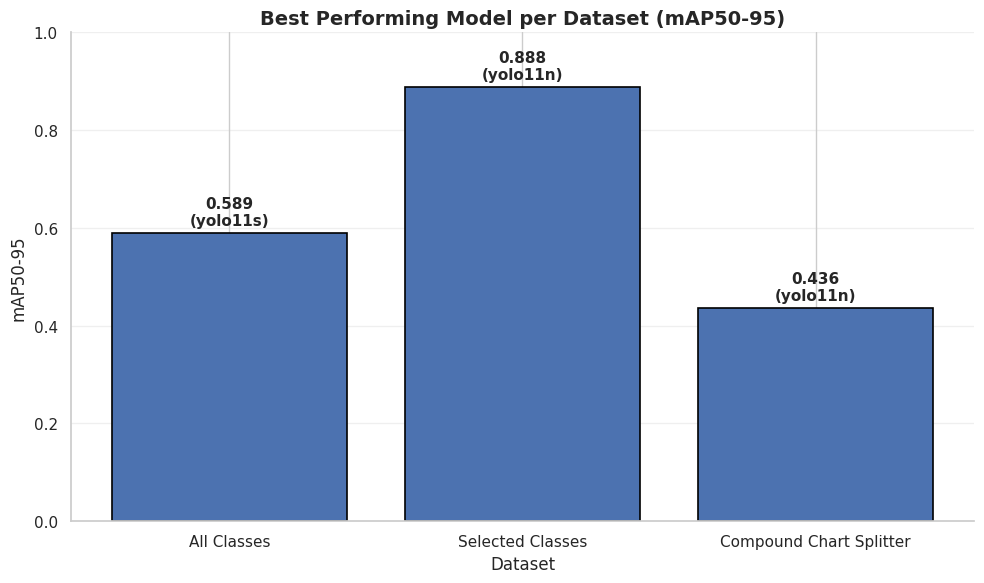

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

best_per_ds = df_general.loc[df_general.groupby('dataset')['mAP50-95'].idxmax()].copy()

dataset_names = {
    '04_all_classes': 'All Classes',
    '05_selected_classes': 'Selected Classes',
    '06_compound_chart_splitter': 'Compound Chart Splitter'
}
best_per_ds['dataset_label'] = best_per_ds['dataset'].map(dataset_names)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(best_per_ds['dataset_label'], best_per_ds['mAP50-95'], edgecolor='black', linewidth=1.2)

for bar, row in zip(bars, best_per_ds.itertuples()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}\n({row.variant})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('mAP50-95', fontsize=12)
ax.set_xlabel('Dataset', fontsize=12)
ax.set_title('Best Performing Model per Dataset (mAP50-95)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(DOCS_DIR / 'best_model_per_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

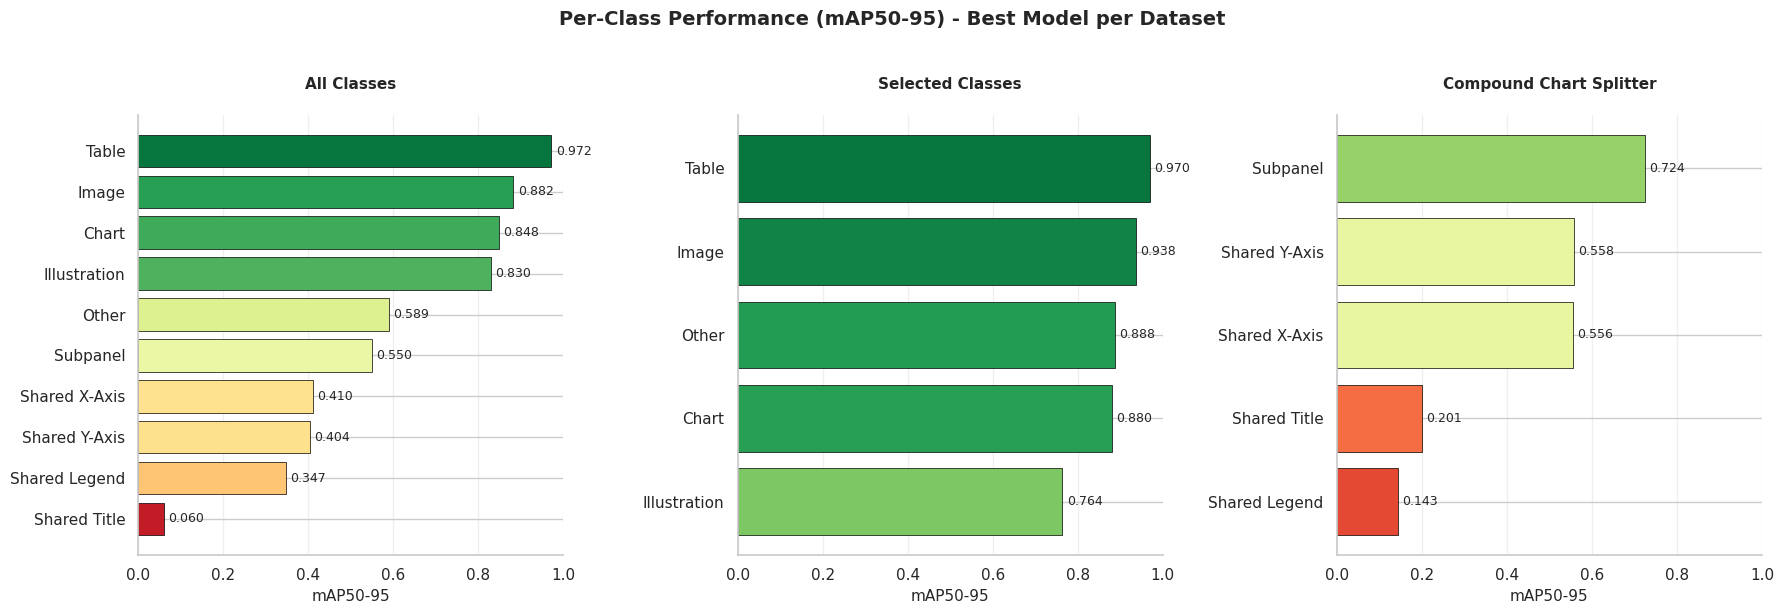

In [ ]:
datasets = df_classes['dataset'].unique()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, dataset in enumerate(sorted(datasets)):
    ax = axes[idx]
    
    best_model = df_general[df_general['dataset'] == dataset].sort_values('mAP50-95', ascending=False).iloc[0]['run_name']

    ds_class_df = df_classes[(df_classes['dataset'] == dataset) & (df_classes['run_name'] == best_model)].copy()
    ds_class_df = ds_class_df.sort_values('mAP50-95', ascending=True)  # Sort for horizontal bar

    colors_gradient = plt.cm.RdYlGn(ds_class_df['mAP50-95'])
    bars = ax.barh(ds_class_df['class'], ds_class_df['mAP50-95'], color=colors_gradient, edgecolor='black', linewidth=0.5)

    for bar, val in zip(bars, ds_class_df['mAP50-95']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
                va='center', fontsize=9)
    
    ax.set_xlim(0, 1.0)
    ax.set_xlabel('mAP50-95', fontsize=11)
    ax.set_title(f'{dataset_names.get(dataset, dataset)}\n', 
                 fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Per-Class Performance (mAP50-95) - Best Model per Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'per_class_performance_by_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

## Qualitative Visualizations

In [ ]:
DOC_ASSETS_DIR = REPO_ROOT / 'docs' / 'assets'
DOC_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

def load_yolo_labels(label_path: Path, img_w: int, img_h: int) -> List[Tuple[int, float, float, float, float]]:
    """Reads YOLO labels and converts normalized xywh to pixel values."""
    boxes = []
    if not label_path.exists():
        return boxes
        
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            cls_id = int(parts[0])
            x_c, y_c, w, h = map(float, parts[1:])
            
            # Convert to x1, y1 (top-left) for plotting
            x1 = int((x_c - w/2) * img_w)
            y1 = int((y_c - h/2) * img_h)
            bw = int(w * img_w)
            bh = int(h * img_h)
            
            boxes.append((cls_id, x1, y1, bw, bh))
    return boxes

def plot_and_save_predictions(model_path, dataset_path, run_name, config, num_samples=10):
    """
    Plots Test images: Left = Ground Truth, Right = Prediction
    Saves to docs/assets/{dataset_name}/{run_name}_{img_name}.png
    """
    dataset_name = dataset_path.name
    save_dir = DOC_ASSETS_DIR / f"{dataset_name}_predictions"
    save_dir.mkdir(parents=True, exist_ok=True)

    test_img_dir = dataset_path / 'images' / 'test'
    test_lbl_dir = dataset_path / 'labels' / 'test'
    
    if not test_img_dir.exists():
        return

    image_files = sorted(list(test_img_dir.glob('*.jpg')) + list(test_img_dir.glob('*.png')))
    if not image_files:
        print(f"No images found in {test_img_dir}")
        return

    k = min(len(image_files), num_samples)
    selected_files = random.sample(image_files, k)
    

    model = YOLO(str(model_path))
    names = model.names
    

    title_str = f"{config.get('variant', 'unk')} | {config.get('image_size', '?')}px | {config.get('epochs', '?')}ep | BS {config.get('batch_size','?')}"
    if 'note' in config:
        title_str += f"\nNote: {config['note']}"

    print(f"Saving {len(selected_files)} images to: {save_dir}")

    for i, img_path in enumerate(selected_files):

        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w, _ = img_rgb.shape
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        plt.suptitle(f"Model: {run_name}\nConfig: {title_str}", fontsize=16)

        ax1.imshow(img_rgb)
        ax1.set_title("Ground Truth", fontsize=14)
        ax1.axis('off')
        
        lbl_file = test_lbl_dir / f"{img_path.stem}.txt"
        gt_boxes = load_yolo_labels(lbl_file, w, h)
        
        for cls_id, x, y, bw, bh in gt_boxes:
            rect = patches.Rectangle((x, y), bw, bh, linewidth=2, edgecolor='lime', facecolor='none')
            ax1.add_patch(rect)
            if cls_id < len(names):
                ax1.text(x, y-5, names[cls_id], color='lime', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))

        ax2.imshow(img_rgb)
        ax2.set_title("Prediction", fontsize=14)
        ax2.axis('off')
        
        results = model.predict(img_rgb, imgsz=IMG_SIZE, conf=CONF_THRES, iou=IOU_THRES, verbose=False)[0]
        
        for box in results.boxes:
            coords = box.xywh[0].cpu().numpy()
            cls_id = int(box.cls[0].item())
            conf = float(box.conf[0].item())
            
            nx, ny, nw, nh = coords
            x1, y1 = nx - nw/2, ny - nh/2
            
            rect = patches.Rectangle((x1, y1), nw, nh, linewidth=2, edgecolor='red', facecolor='none')
            ax2.add_patch(rect)
            ax2.text(x1, y1-5, f"{names[cls_id]} {conf:.2f}", color='red', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))

        plt.tight_layout()

        out_filename = f"{run_name}_{img_path.stem}.png"
        out_path = save_dir / out_filename
        plt.savefig(out_path)

        plt.show()
        plt.close()


if not df_general.empty:
    unique_datasets = df_general['dataset'].unique()
    
    for ds_name in unique_datasets:
        ds_subset = df_general[df_general['dataset'] == ds_name]

        best_row = ds_subset.sort_values(by='mAP50-95', ascending=False).iloc[0]
        
        run_name = best_row['run_name']
        ds_path = DATASET_DIR / ds_name

        model_config = MODEL_CONFIGS.get(run_name, {})

        model_path = RUNS_DIR / ds_name / run_name / 'weights' / 'best.pt'
        
        print(f"\n{'='*60}")
        print(f" Visualizing BEST model in {ds_name}:")
        print(f" -> {run_name}")
        print(f" -> {model_config}")
        print(f"{'='*60}")
        
        plot_and_save_predictions(model_path, ds_path, run_name, model_config, num_samples=10)
